# CityScape - Segmentation sémantique des images

### Table des matières

* [**1. Introduction**](#chapter1)
* [**2. Analyse des données**](#chapter2)
    * [2.1. Dataset](#section_2_1)
    * [2.2. Répertoires](#section_2_2)
    * [2.3. Fichiers](#section_2_3)  
    * [2.4. Labels](#section_2_4)
* [**3. Préparations**](#chapter3)
    * [3.1. Labels](#section_3_1)
    * [3.2. Chargement des données](#section_3_2)
    * [3.3. Générateur de données](#section_3_3)
    * [3.4. Augmentation](#section_3_4)
    * [3.5. Générateur de données complet](#section_3_5)
* [**4. Modélisation**](#chapter4)
    * [4.1. Fonctions](#section_4_1)
    * [4.2. Initialisations](#section_4_2)
    * [4.3. Modélisation](#section_4_3)
    * [4.4. Résultats](#section_4_4)
    * [4.5. Evaluation](#section_4_5)
* [**5. Prédictions**](#chapter5)    
* [**6. Jeu de test**](#chapter6)    
* [**7. Conclusion**](#chapter7)    

## 1 - Introduction <a class="anchor" id="chapter1"></a>

Cette étude s'inscrit dans le projet de voitures autonomes.  
L'objectif est de créer un modèle capable de segmenter des images de scènes urbaines.  

## 2 - Analyse des données <a class="anchor" id="chapter2"></a>

In [522]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import seaborn as sns

%matplotlib inline
sns.set()

### 2.1 - Le dataset <a class="anchor" id="section_2_1"></a>

Le dataset est composé de deux répertoires:  
    P8_Cityscapes_leftImg8bit_trainvaltest qui contient les images source  
    P8_Cityscapes_gtFine_trainvaltest qui contient les masques  
    
Chaque répertoire contient les répertoires train / val / test  


In [25]:
datas_path = './datas/'

images_dir = datas_path + 'P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/'
masks_dir = datas_path + 'P8_Cityscapes_gtFine_trainvaltest/gtFine/'

train_images_dir = images_dir + 'train/'
val_images_dir = images_dir + 'val/'
test_images_dir = images_dir + 'test/'

train_masks_dir = masks_dir + 'train/'
val_masks_dir = masks_dir + 'val/'
test_masks_dir = masks_dir + 'test/'

### 2.2 - Contenu des répertoires <a class="anchor" id="section_2_2"></a>

#### Aperçu du répertoire train_images_dir:

In [26]:
print(os.listdir(train_images_dir))

['aachen', 'bochum', 'bremen', 'cologne', 'darmstadt', 'dusseldorf', 'erfurt', 'hamburg', 'hanover', 'jena', 'krefeld', 'monchengladbach', 'strasbourg', 'stuttgart', 'tubingen', 'ulm', 'weimar', 'zurich']


Le répertoire contient une liste de répertoires de villes.  

#### Nombre de villes par train/val/test:

In [27]:
print('Nombre de villes:')
print(f'images train : {len(os.listdir(train_images_dir))}')
print(f'masques train : {len(os.listdir(train_masks_dir))}')
print(f'images val : {len(os.listdir(val_images_dir))}')
print(f'masques val : {len(os.listdir(val_masks_dir))}')
print(f'images test : {len(os.listdir(test_images_dir))}')
print(f'masques test : {len(os.listdir(test_masks_dir))}')


Nombre de villes:
images train : 18
masques train : 18
images val : 3
masques val : 3
images test : 6
masques test : 6


Les répertoires images/masques contiennent les mêmes répertoires.

#### Contenu des répertoires images et masques (train) pour une ville :  

In [28]:
list_example = os.listdir(train_images_dir + os.listdir(train_images_dir)[7])
print('10 premiers fichiers du répertoire d\'image (train):\n')
print(list_example[:10])
print('\n')
list_example = os.listdir(train_masks_dir + os.listdir(train_masks_dir)[7])
print('10 premiers fichiers du répertoire de masques (train):\n')
print(list_example[:10])
      

10 premiers fichiers du répertoire d'image (train):

['hamburg_000000_000042_leftImg8bit.png', 'hamburg_000000_000629_leftImg8bit.png', 'hamburg_000000_001106_leftImg8bit.png', 'hamburg_000000_001613_leftImg8bit.png', 'hamburg_000000_002095_leftImg8bit.png', 'hamburg_000000_002338_leftImg8bit.png', 'hamburg_000000_003488_leftImg8bit.png', 'hamburg_000000_003904_leftImg8bit.png', 'hamburg_000000_004985_leftImg8bit.png', 'hamburg_000000_005639_leftImg8bit.png']


10 premiers fichiers du répertoire de masques (train):

['hamburg_000000_000042_gtFine_color.png', 'hamburg_000000_000042_gtFine_instanceIds.png', 'hamburg_000000_000042_gtFine_labelIds.png', 'hamburg_000000_000042_gtFine_polygons.json', 'hamburg_000000_000629_gtFine_color.png', 'hamburg_000000_000629_gtFine_instanceIds.png', 'hamburg_000000_000629_gtFine_labelIds.png', 'hamburg_000000_000629_gtFine_polygons.json', 'hamburg_000000_001106_gtFine_color.png', 'hamburg_000000_001106_gtFine_instanceIds.png']


Les images contiennent un numéro de fichier différent pour chaque fichier image.  
Les labels contiennent 4 fichiers par numéro, suivis de color, instanceIds, labelIds, polygons.

#### Nombre de fichiers par répertoire:

In [29]:

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def check_count(df_check_count, images_dir, masks_dir, type_dir):
    for town_dir in os.listdir(images_dir):
        images_list = os.listdir(images_dir + town_dir)
        masks_list = os.listdir(masks_dir + town_dir)
        curr_check_count={}
        curr_check_count['type'] = type_dir
        curr_check_count['ville'] = town_dir
        curr_check_count['images'] = len(images_list)
        curr_check_count['color mask'] = len([x for x in masks_list if "color" in x ])
        curr_check_count['instanceIds mask'] = len([x for x in masks_list if "instanceIds" in x ])
        curr_check_count['labelIds mask'] = len([x for x in masks_list if "labelIds" in x ])
        curr_check_count['polygons mask'] = len([x for x in masks_list if "polygons" in x ])
        curr_check_count['total masks'] = len(masks_list)
        df_check_count = df_check_count.append(curr_check_count,ignore_index=True)
    return df_check_count

df_check_count = pd.DataFrame(columns=['type', 'ville', 'images', 'color mask', 'instanceIds mask','labelIds mask','polygons mask','total masks'])
df_check_count = check_count(df_check_count, train_images_dir, train_masks_dir, 'train')
df_check_count = check_count(df_check_count, val_images_dir, val_masks_dir, 'val')
df_check_count = check_count(df_check_count, test_images_dir, test_masks_dir, 'test')

df_check_count



,type,ville,images,color mask,instanceIds mask,labelIds mask,polygons mask,total masks
0,train,aachen,174,174,174,174,174,696
1,train,bochum,96,96,96,96,96,384
2,train,bremen,316,316,316,316,316,1264
3,train,cologne,154,154,154,154,154,616
4,train,darmstadt,85,85,85,85,85,340
5,train,dusseldorf,221,221,221,221,221,884
6,train,erfurt,109,109,109,109,109,436
7,train,hamburg,248,248,248,248,248,992
8,train,hanover,196,196,196,196,196,784
9,train,jena,119,119,119,119,119,476


Pour une image, correspond:  

    - un fichier color  
    - un fichier instanceIds  
    - un fichier labelIds  
    - un fichier polygons  
    
dans les répertoires train, val et test

#### Nombre de fichiers regroupés par train/val/test:

In [555]:
def folder_file_count(folder):
    "count the number of files in a directory"
    count = 0
    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)
        if os.path.isfile(path):
            count += 1
        elif os.path.isdir(path):
            count += folder_file_count(path)
    return count

df_check_count_group = pd.DataFrame(columns=['type', 'images', 'masks'])

for type_dir in os.listdir(images_dir):
    curr_check_count_group={}
    curr_check_count_group['type'] = type_dir
    curr_check_count_group['images'] = folder_file_count(images_dir + type_dir)
    curr_check_count_group['masks'] = int(folder_file_count(masks_dir + type_dir) / 4)
    df_check_count_group = df_check_count_group.append(curr_check_count_group,ignore_index=True)
    
total = df_check_count_group.sum()
total['type'] = 'total'
df_check_count_group = df_check_count_group.append(total.transpose(), ignore_index=True)
        
df_check_count_group



,type,images,masks
0,test,1525,1525
1,train,2975,2975
2,val,500,500
3,total,5000,5000


### 2.3 - Fichiers <a class="anchor" id="section_2_3"></a>

In [510]:
def affiche_image(image, title = None, grid_bool = False):
    if title is not None:
        plt.title(title)
    plt.grid(grid_bool)
    plt.imshow(image)
    
def get_file(type_dir, town_pos, file_pos):
    folder_images = images_dir + type_dir + '/'
    filepath = folder_images + os.listdir(folder_images)[town_pos] + '/' 
    filename = os.listdir(folder_images + os.listdir(folder_images)[town_pos])[file_pos]
    image_file = filepath + filename

    filename_number = str(filename).replace('_leftImg8bit','').replace('.png','')
    
    folder_masques = masks_dir + type_dir + '/'
    filepath = folder_masques + os.listdir(folder_masques)[town_pos] + '/' 
    masks_list = os.listdir(folder_masques + os.listdir(folder_masques)[town_pos])
    masks_list = [x for x in masks_list if filename_number in x]

    color_file = filepath + [x for x in masks_list if "color" in x ][0]
    instance_file = filepath + [x for x in masks_list if "instanceIds" in x ][0]
    label_file = filepath + [x for x in masks_list if "labelIds" in x ][0]
    
    return  image_file, color_file, instance_file, label_file    

#### Chargement du path d'une image et des masques associés

In [511]:
image_file, color_file, instance_file, label_file = get_file('train',0,0)

#### Aperçu des fichiers

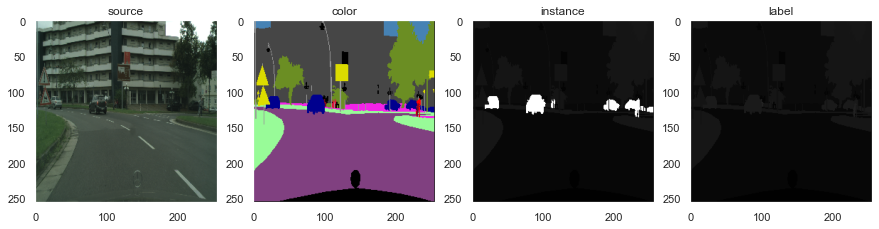

In [512]:

plt.figure(figsize=(15,10))
plt.subplot(1,4,1)
affiche_image(image.load_img(image_file, target_size=(256, 256)), 'source')
plt.subplot(1,4,2)
affiche_image(image.load_img(color_file, target_size=(256, 256)), 'color')
plt.subplot(1,4,3)
affiche_image(image.load_img(instance_file, target_size=(256, 256)), 'instance')
plt.subplot(1,4,4)
affiche_image(image.load_img(label_file, target_size=(256, 256)), 'label')


#### Dimensions des fichiers

In [36]:
print(f'Dimensions image file : {image.img_to_array(image.load_img(image_file)).shape}')
print(f'Dimensions color file : {image.img_to_array(image.load_img(color_file)).shape}')
print(f'Dimensions instance file : {image.img_to_array(image.load_img(instance_file)).shape}')
print(f'Dimensions label file : {image.img_to_array(image.load_img(label_file)).shape}')

Dimensions image file : (1024, 2048, 3)
Dimensions color file : (1024, 2048, 3)
Dimensions instance file : (1024, 2048, 3)
Dimensions label file : (1024, 2048, 3)


### 2.4 - Labels <a class="anchor" id="section_2_4"></a>

In [37]:
np.unique(image.img_to_array(image.load_img(label_file)))

array([ 0.,  1.,  3.,  4.,  7.,  8., 11., 17., 20., 21., 22., 23., 24.,
       25., 26., 33.], dtype=float32)

Les valeurs vont de 0 à 33, soit 34 valeurs.  
Le fichier label contient les valeurs de labels des pixels

In [38]:
np.unique(image.img_to_array(image.load_img(color_file)))

array([  0.,  11.,  20.,  32.,  35.,  60.,  64.,  70., 107., 119., 128.,
       130., 142., 152., 153., 180., 220., 232., 244., 251., 255.],
      dtype=float32)

Les valeurs vont de 0 à 255
Le fichier color contient les valeurs RGB de l'image segmentée.

## 3 - Préparations <a class="anchor" id="chapter3"></a>

### 3.1 - Labels <a class="anchor" id="section_3_1"></a>

#### Correspondance des labels et categories

Le tableau ci-dessous définit la catégorie de chaque label

In [39]:
# https://github.com/mcordts/cityscapesScripts/blob/master/cityscapesscripts/helpers/labels.py

labels = [
            (                   "name","id", "trainId",         "category",  "catId","hasInstances","ignoreInEval",        "color"),
            (  'unlabeled'            ,  0 ,      255 , 'void'            , 0       , False        , True         , (  0,  0,  0) ),
            (  'ego vehicle'          ,  1 ,      255 , 'void'            , 0       , False        , True         , (  0,  0,  0) ),
            (  'rectification border' ,  2 ,      255 , 'void'            , 0       , False        , True         , (  0,  0,  0) ),
            (  'out of roi'           ,  3 ,      255 , 'void'            , 0       , False        , True         , (  0,  0,  0) ),
            (  'static'               ,  4 ,      255 , 'void'            , 0       , False        , True         , (  0,  0,  0) ),
            (  'dynamic'              ,  5 ,      255 , 'void'            , 0       , False        , True         , (111, 74,  0) ),
            (  'ground'               ,  6 ,      255 , 'void'            , 0       , False        , True         , ( 81,  0, 81) ),
            (  'road'                 ,  7 ,        0 , 'flat'            , 1       , False        , False        , (128, 64,128) ),
            (  'sidewalk'             ,  8 ,        1 , 'flat'            , 1       , False        , False        , (244, 35,232) ),
            (  'parking'              ,  9 ,      255 , 'flat'            , 1       , False        , True         , (250,170,160) ),
            (  'rail track'           , 10 ,      255 , 'flat'            , 1       , False        , True         , (230,150,140) ),
            (  'building'             , 11 ,        2 , 'construction'    , 2       , False        , False        , ( 70, 70, 70) ),
            (  'wall'                 , 12 ,        3 , 'construction'    , 2       , False        , False        , (102,102,156) ),
            (  'fence'                , 13 ,        4 , 'construction'    , 2       , False        , False        , (190,153,153) ),
            (  'guard rail'           , 14 ,      255 , 'construction'    , 2       , False        , True         , (180,165,180) ),
            (  'bridge'               , 15 ,      255 , 'construction'    , 2       , False        , True         , (150,100,100) ),
            (  'tunnel'               , 16 ,      255 , 'construction'    , 2       , False        , True         , (150,120, 90) ),
            (  'pole'                 , 17 ,        5 , 'object'          , 3       , False        , False        , (153,153,153) ),
            (  'polegroup'            , 18 ,      255 , 'object'          , 3       , False        , True         , (153,153,153) ),
            (  'traffic light'        , 19 ,        6 , 'object'          , 3       , False        , False        , (250,170, 30) ),
            (  'traffic sign'         , 20 ,        7 , 'object'          , 3       , False        , False        , (220,220,  0) ),
            (  'vegetation'           , 21 ,        8 , 'nature'          , 4       , False        , False        , (107,142, 35) ),
            (  'terrain'              , 22 ,        9 , 'nature'          , 4       , False        , False        , (152,251,152) ),
            (  'sky'                  , 23 ,       10 , 'sky'             , 5       , False        , False        , ( 70,130,180) ),
            (  'person'               , 24 ,       11 , 'human'           , 6       , True         , False        , (220, 20, 60) ),
            (  'rider'                , 25 ,       12 , 'human'           , 6       , True         , False        , (255,  0,  0) ),
            (  'car'                  , 26 ,       13 , 'vehicle'         , 7       , True         , False        , (  0,  0,142) ),
            (  'truck'                , 27 ,       14 , 'vehicle'         , 7       , True         , False        , (  0,  0, 70) ),
            (  'bus'                  , 28 ,       15 , 'vehicle'         , 7       , True         , False        , (  0, 60,100) ),
            (  'caravan'              , 29 ,      255 , 'vehicle'         , 7       , True         , True         , (  0,  0, 90) ),
            (  'trailer'              , 30 ,      255 , 'vehicle'         , 7       , True         , True         , (  0,  0,110) ),
            (  'train'                , 31 ,       16 , 'vehicle'         , 7       , True         , False        , (  0, 80,100) ),
            (  'motorcycle'           , 32 ,       17 , 'vehicle'         , 7       , True         , False        , (  0,  0,230) ),
            (  'bicycle'              , 33 ,       18 , 'vehicle'         , 7       , True         , False        , (119, 11, 32) ),
            (  'license plate'        , -1 ,       -1 , 'vehicle'         , 7       , False        , True         , (  0,  0,142) ),
        ]

#### Création d'un dictionnaire associant chaque label au nom de la catégorie

In [239]:
df_labels = pd.DataFrame(
    labels, columns=str(
        labels[0]).replace(
        '(','').replace(
        ')','').replace(
        '\'','').split(
        ", ")).iloc[1: , :].reset_index()

categories={}
for cat_id in np.unique(df_labels['catId']):
    cat_list = df_labels[df_labels['catId']==cat_id]['id'].to_list()
    cat_name = np.unique(df_labels[df_labels['catId']==cat_id]['category'])[0]
    categories[cat_name]=cat_list
    

In [240]:
categories

{'void': [0, 1, 2, 3, 4, 5, 6],
 'flat': [7, 8, 9, 10],
 'construction': [11, 12, 13, 14, 15, 16],
 'object': [17, 18, 19, 20],
 'nature': [21, 22],
 'sky': [23],
 'human': [24, 25],
 'vehicle': [26, 27, 28, 29, 30, 31, 32, 33, -1]}

#### Creation du nouveau format des labels

In [158]:
def img_mask(img):
    img = np.squeeze(img)
    mask = np.zeros((img.shape[0], img.shape[1], 8))

    for i in range(-1, 34):
        if i in categories['void']:
            mask[:,:,0] = np.logical_or(mask[:,:,0],(img==i))
        elif i in categories['flat']:
            mask[:,:,1] = np.logical_or(mask[:,:,1],(img==i))
        elif i in categories['construction']:
            mask[:,:,2] = np.logical_or(mask[:,:,2],(img==i))
        elif i in categories['object']:
            mask[:,:,3] = np.logical_or(mask[:,:,3],(img==i))
        elif i in categories['nature']:
            mask[:,:,4] = np.logical_or(mask[:,:,4],(img==i))
        elif i in categories['sky']:
            mask[:,:,5] = np.logical_or(mask[:,:,5],(img==i))
        elif i in categories['human']:
            mask[:,:,6] = np.logical_or(mask[:,:,6],(img==i))
        elif i in categories['vehicle']:
            mask[:,:,7] = np.logical_or(mask[:,:,7],(img==i))
    return mask


#### Test du nouveau format

In [230]:

# get a label file, transform in array, and generate new format mask array 
_, _, _, tmp_label = get_file('train', 0, 0)
tmp_label_array = image.img_to_array(image.load_img(tmp_label, grayscale=True))
test_mask = img_mask(tmp_label_array)

# get one pixel example by category in the label file
categories_examples={}
for i in range(-1, 34):
    find_pixel = np.where(tmp_label_array == i)
    if len(find_pixel[0])>0:
        categories_examples[i] = [find_pixel[0][0],find_pixel[1][0]]

# get initial value, category and new label value for each pixel example
df_test_mask = pd.DataFrame(columns=['pixel pos', 'initial label value', 'categorie', 'new label value'])
for i in categories_examples:
    curr_categ={}
    initial_value = tmp_label_array[categories_examples[i][0]][categories_examples[i][1]]
    curr_categ['pixel pos'] = categories_examples[i]
    curr_categ['initial label value'] = int(initial_value)
    curr_categ['categorie'] = [k for k, v in categories.items() if initial_value in v][0].replace('\'','')
    curr_categ['new label value'] = test_mask[categories_examples[i][0]][categories_examples[i][1]]
    df_test_mask = df_test_mask.append(curr_categ, ignore_index=True)

    

In [232]:
df_test_mask

,pixel pos,initial label value,categorie,new label value
0,"[498, 1865]",0,void,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,"[844, 1136]",1,void,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,"[0, 0]",3,void,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
3,"[17, 778]",4,void,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
4,"[488, 6]",7,flat,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
5,"[464, 305]",8,flat,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
6,"[5, 197]",11,construction,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
7,"[5, 20]",17,object,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]"
8,"[247, 929]",20,object,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]"
9,"[5, 1633]",21,nature,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"


### 3.2 - Chargement des données <a class="anchor" id="section_3_2"></a>

Création d'une fonction permettant, à partir d'un nombre d'entrainement et une proportion de validation, de générer  :  
- une liste d’images pour l’entraînement  
- une liste de masques pour l’entraînement  
- une liste d’images pour la validation  
- une liste de masques pour la validation  

Afin d’utiliser des données réparties au mieux sur l’ensemble du jeu de données, la fonction répartit les données parmi les villes disponibles en tailles égales.


In [241]:
import os

def load_data(sample_size = None, val_split = 0.1, data_type = 'train'):
    
    if data_type == 'train':
    
        val_size = calc_val_sizes(train_images_dir, sample_size, val_split)

        train_images_list = get_files_list(train_images_dir, sample_size)
        train_mask_list = get_files_list(train_masks_dir, sample_size, label_files=True)
        val_images_list = get_files_list(val_images_dir, val_size)
        val_mask_list = get_files_list(val_masks_dir, val_size, label_files=True)

        return train_images_list, val_images_list, train_mask_list, val_mask_list

    else: # test files
        
        test_images_list = get_files_list(test_images_dir, sample_size)
        test_mask_list = get_files_list(test_masks_dir, sample_size, label_files=True)
        
        return test_images_list, test_mask_list
    

def calc_val_sizes(images_dir, sample_size, val_split):
   
    sample_size = sample_size if sample_size is not None else folder_file_count(images_dir)
    val_size = 0

    if val_split>=1:
        val_size = int(val_split)
        
    if 0<=val_split<1:
        val_size = int(sample_size * val_split)   
        
    return val_size


def get_files_list(file_dir, file_count = None, label_files = False):
    
    files_list=[]
    
    # get splitted files count per folder 
    if file_count is not None:
        files_count_per_dir = split_files_count_per_dir(file_dir,file_count)
    
    # get files paths
    for idx,town_dir in enumerate(os.listdir(file_dir)):
        
        current_files_count = None
        current_file_list = os.listdir(file_dir + town_dir)
        current_file_list = [file_dir + town_dir + '/' + filename for filename in current_file_list]
        
        if label_files:
            current_file_list = [x for x in current_file_list if "labelIds" in x ]
        
        if file_count is not None:
            current_files_count = int(files_count_per_dir[idx])
            
        files_list.extend(current_file_list[:current_files_count])
    
    return files_list


def split_files_count_per_dir(file_dir,file_count,label_files = False):
    
    # check sample < file counts
    files_type_count = 1 if not label_files else 4
    if folder_file_count(file_dir) < file_count * files_type_count:
        print('not enough files')
        return np.zeros(len(os.listdir(file_dir)))
    
    # split sample count in folder count
    split_towns_dir = np.array_split(np.arange(file_count), len(os.listdir(file_dir)))

    # 2d array with 1 column with files counts in dirs and 1 column with split array result
    town_files = np.zeros((len(os.listdir(file_dir)),2))
    for idx,town_dir in enumerate(os.listdir(file_dir)):
        file_list = os.listdir(file_dir + town_dir)
        if label_files:
            file_list = [x for x in file_list if "labelIds" in x ]
        town_files[idx][0] = len(file_list)
        town_files[idx][1] = len(split_towns_dir[idx])
        
    # check missing files in each town dir versus split array result 
    missing_files = 0
    for files_in_dirs,files_in_split in town_files:
        missing_files = (missing_files + files_in_split-files_in_dirs if files_in_dirs<files_in_split else missing_files)

    # resize split array result in order to files count, add missing files count to next folder
    for idx,town_files_line in enumerate(town_files):
        diff = town_files_line[0]-town_files_line[1]
        town_files[idx][1] = town_files[idx][1] if diff>=0 else town_files[idx][0]
        add = missing_files if diff>missing_files else (diff if diff>0 else 0)
        town_files[idx][1] = town_files[idx][1] + add
        missing_files = missing_files - add

    # file count list to get in each ton folder
    splitted_files_count = [int(row[1]) for row in town_files]

    return splitted_files_count


In [493]:
train_images_list, val_images_list, train_mask_list, val_mask_list = load_data(sample_size = 10, val_split = 2)
print(f'\n- sample_size: 10, val_split : 2')
print(f'    train images: {len(train_images_list)}\n    train masks: {len(train_mask_list)}')
print(f'    val images: {len(val_images_list)}\n    val masks: {len(val_mask_list)}')    
# print('\n')
print(f'\n- sample_size: 30, val_split : 0.1')
train_images_list, val_images_list, train_mask_list, val_mask_list = load_data(sample_size = 30, val_split = 0.1)
print(f'    train images: {len(train_images_list)}\n    train masks: {len(train_mask_list)}')
print(f'    val images: {len(val_images_list)}\n    val masks: {len(val_mask_list)}')    
    


- sample_size: 10, val_split : 2
    train images: 10
    train masks: 10
    val images: 2
    val masks: 2

- sample_size: 30, val_split : 0.1
    train images: 30
    train masks: 30
    val images: 3
    val masks: 3


### 3.3 - Générateur de données <a class="anchor" id="section_3_3"></a>

Création d'un générateur de données permettant de ne pas charger toutes les images en une seule fois

In [523]:
from tensorflow.python.keras.preprocessing import image
from tensorflow.keras.utils import Sequence

In [497]:
class seg_gen_test(Sequence):
    def __init__(self, x_set, y_set, batch_size):
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.x) / float(self.batch_size)))

    def __getitem__(self, idx):
        
        batch_x, batch_y = [], []

        batch_x = self.x[idx * self.batch_size:(idx + 1) *
        self.batch_size]
        
        batch_y = self.y[idx * self.batch_size:(idx + 1) *
        self.batch_size]

        batch_x = [
            image.img_to_array(image.load_img(filepath, target_size=(256, 256)))/255.
               for filepath in batch_x]
        
        batch_y = [
            image.img_to_array(image.load_img(filepath, grayscale=True, target_size=(256, 256)))
               for filepath in batch_y]
            
        if test_with_img_msk:
            batch_y = list(map(img_mask, batch_y)) # preprocess labels

        return np.array(batch_x), np.array(batch_y)



In [495]:
train_images_list, val_images_list, train_mask_list, val_mask_list = load_data(sample_size = 15, val_split = 0)


In [499]:
def simulate_sequence(train_gen):
    loop_iter = 0
    while True:
        x,y = train_gen.__getitem__(loop_iter)
        if x.shape[0] == 0:
            break
        if loop_iter == 0:
            print(f'Valeur du pixel 100,100 de la première image : {y[0][100][100]}')
        print(f'batch {loop_iter}:')
        print(f'  x shape {x.shape}')
        print(f'  y shape {y.shape}')
        # security loop
        if loop_iter>10:
            break
        loop_iter += 1
    

# test sans image masque
batch_size = 4
train_gen = seg_gen_test(train_images_list, train_mask_list, batch_size)
print(f'Nombre de fichiers : {len(train_images_list)}')
print(f'Taille des batchs : {batch_size}')
print(f'Nombre de séquences : {train_gen.__len__()}')

test_with_img_msk = False
print('\nSans img_msk:')
simulate_sequence(train_gen)

test_with_img_msk = True
train_gen = seg_gen_test(train_images_list, train_mask_list, batch_size)
print('\nAvec img_msk:')
simulate_sequence(train_gen)


Nombre de fichiers : 15
Taille des batchs : 4
Nombre de séquences : 4

Sans img_msk:
Valeur du pixel 100,100 de la première image : [11.]
batch 0:
  x shape (4, 256, 256, 3)
  y shape (4, 256, 256, 1)
batch 1:
  x shape (4, 256, 256, 3)
  y shape (4, 256, 256, 1)
batch 2:
  x shape (4, 256, 256, 3)
  y shape (4, 256, 256, 1)
batch 3:
  x shape (3, 256, 256, 3)
  y shape (3, 256, 256, 1)

Avec img_msk:
Valeur du pixel 100,100 de la première image : [0. 0. 1. 0. 0. 0. 0. 0.]
batch 0:
  x shape (4, 256, 256, 3)
  y shape (4, 256, 256, 8)
batch 1:
  x shape (4, 256, 256, 3)
  y shape (4, 256, 256, 8)
batch 2:
  x shape (4, 256, 256, 3)
  y shape (4, 256, 256, 8)
batch 3:
  x shape (3, 256, 256, 3)
  y shape (3, 256, 256, 8)


### 3.4 - Augmentation <a class="anchor" id="section_3_4"></a>

Création d'une fonction permettant l'augmentation de données et tests d'intégrations avec le générateur

In [301]:

import albumentations as A


In [302]:
def plot_augment_test(image_file, augmented_image, label_file, augmented_mask):
    plt.figure(figsize=(15,8))
    plt.subplot(2,4,1)
    affiche_image(image_file, 'image')
    plt.subplot(2,4,2)
    affiche_image(augmented_image, 'image augmented')
    plt.subplot(2,4,3)
    affiche_image(label_file, 'mask')
    plt.subplot(2,4,4)
    affiche_image(augmented_mask, 'mask augmented')

In [303]:
image_file, color_file, instance_file, label_file = get_file('train',0,0)

image_file_array = image.img_to_array(image.load_img(image_file, target_size=(256, 256)))/255. 
label_file_array = image.img_to_array(image.load_img(color_file, target_size=(256, 256)))/255.


In [304]:
transformHP = A.HorizontalFlip()
transformGB = A.GaussianBlur()
transformRBC = A.RandomBrightnessContrast()

augmentedHP = transformHP(image = image_file_array, mask = label_file_array)
augmentedGB = transformGB(image = image_file_array, mask = label_file_array)
augmentedRBC = transformRBC(image = image_file_array, mask = label_file_array)

HorizontalFlip:


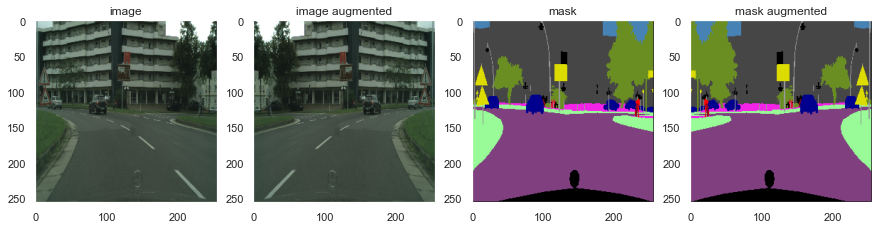

In [317]:
print('HorizontalFlip:')
plot_augment_test(image_file_array, augmentedHP['image'], label_file_array, augmentedHP['mask'])

GaussianBlur:


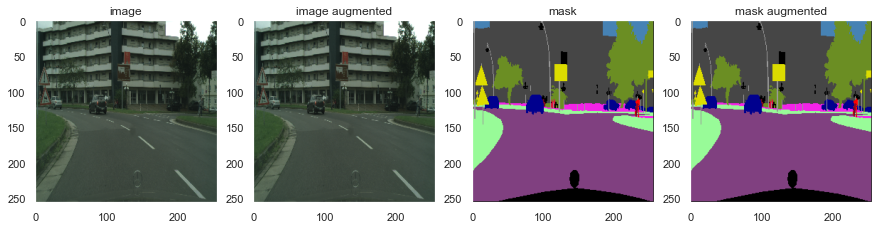

In [318]:
print('GaussianBlur:')
plot_augment_test(image_file_array, augmentedGB['image'], label_file_array, augmentedGB['mask'])

RandomBrightnessContrast:


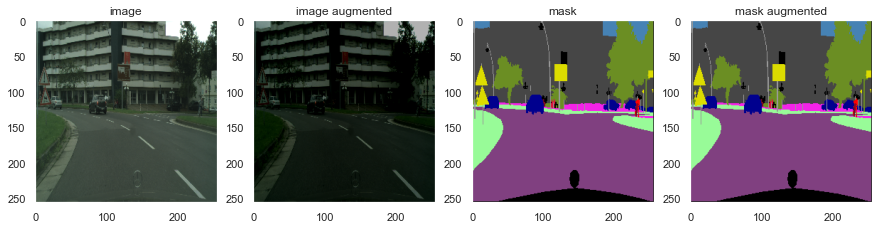

In [319]:
print('RandomBrightnessContrast:')
plot_augment_test(image_file_array, augmentedRBC['image'], label_file_array, augmentedRBC['mask'])

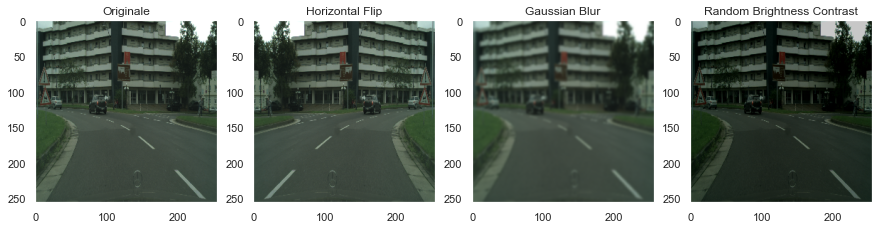

In [577]:
plt.figure(figsize=(15,8))
plt.subplot(1,4,1)
affiche_image(image_file_array, 'Originale')
plt.subplot(1,4,2)
affiche_image(augmentedHP['image'], 'Horizontal Flip')
plt.subplot(1,4,3)
affiche_image(augmentedGB['image'], 'Gaussian Blur')
plt.subplot(1,4,4)
affiche_image(augmentedRBC['image'], 'Random Brightness Contrast')

#### test augmentation compose

In [320]:
def augment_image_labels(_image, _mask):
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.GaussianBlur(p=0.5),
        A.RandomBrightnessContrast(p=0.5)
    ],p=0.5)

    augmented = transform(image = _image, mask = _mask)

    return augmented


Compose three transforms:


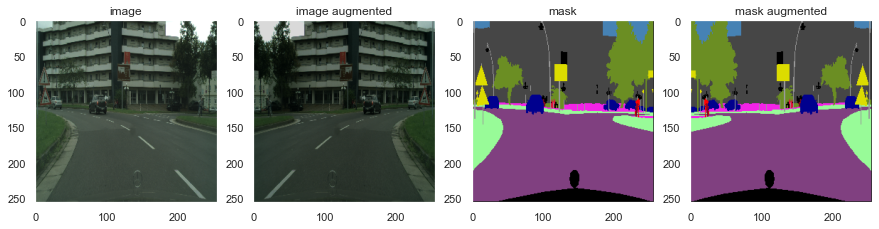

In [330]:
augmented = augment_image_labels(image_file_array, label_file_array)
print('Compose three transforms:')
plot_augment_test(image_file_array, augmented['image'], label_file_array, augmented['mask'])

#### test augmentation with keras preprocessing

In [334]:
from tensorflow.keras.applications.vgg16 import preprocess_input as keras_preprocess_input_vgg16
from tensorflow.keras.applications.resnet50 import preprocess_input as keras_preprocess_input_resnet


In [428]:
def plot_augment_keras_test():
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    affiche_image((source_preprocessed * 255).astype(np.uint8), 'source')
    plt.subplot(1,2,2)
    affiche_image((aug_preprocessed * 255).astype(np.uint8), 'augmented')
    plt.show()   
    

In [436]:
image_file, color_file, instance_file, label_file = get_file('train',0,0)

image_file_array = image.img_to_array(image.load_img(image_file, target_size=(224, 224)))

augmented = augment_image_labels(image_file_array, label_file_array)
augmented_image = augmented['image']

source_preprocessed = image_file_array.copy()
aug_preprocessed = augmented_image.copy()

source_preprocessed = keras_preprocess_input_resnet(source_preprocessed)
aug_preprocessed = keras_preprocess_input_resnet(aug_preprocessed)


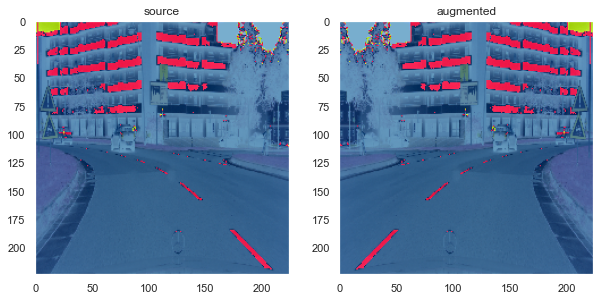

In [437]:
plot_augment_keras_test()

#### test augment batch

In [490]:
train_images_list2, val_images_list2, train_mask_list2, val_mask_list2 = load_data(
    sample_size = 2, 
    val_split = 1, 
    data_type = 'train')

batch_x = [
    image.img_to_array(image.load_img(filepath, target_size=(224,224)))/255.
       for filepath in train_images_list2]

batch_y = [
    image.img_to_array(image.load_img(filepath, grayscale=True, target_size=(224,224)))
       for filepath in train_mask_list2]

batch_aug = list(map(augment_image_labels, batch_x, batch_y)) 


First element of batch:


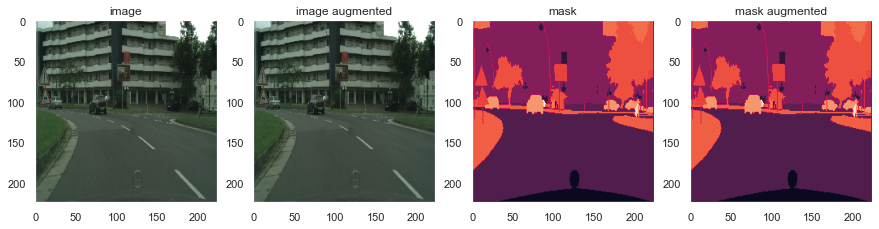

In [491]:
batch_nb = 0
print('First element of batch:')
plot_augment_test(batch_x[batch_nb], batch_aug[batch_nb]['image'], batch_y[batch_nb], batch_aug[batch_nb]['mask'])

Second element of batch:


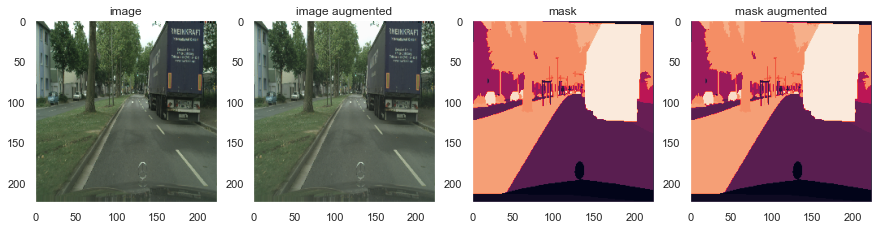

In [492]:
batch_nb = 1
print('Second element of batch:')
plot_augment_test(batch_x[batch_nb], batch_aug[batch_nb]['image'], batch_y[batch_nb], batch_aug[batch_nb]['mask'])

### 3.5 - Générateur de données complet <a class="anchor" id="section_3_5"></a>

Classe de génération de données avec augmentation, image mask, keras preprocessing :

In [235]:
class DataGenerator(Sequence):
    
    def __init__(self, x_set, y_set, batch_size, input_dims, preprocessing=None, augment=False):
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size
        self.input_dims = input_dims
        self.preprocessing = preprocessing
        self.augment = augment

    def __len__(self):
        return int(np.ceil(len(self.x) / float(self.batch_size)))

    def __getitem__(self, idx):
        
        batch_x, batch_y = [], []

        batch_x = self.x[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.y[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_x = [
            image.img_to_array(image.load_img(filepath, target_size=self.input_dims))
               for filepath in batch_x]
        
        batch_y = [
            image.img_to_array(image.load_img(filepath, grayscale=True, target_size=self.input_dims))
               for filepath in batch_y]
        
        if self.augment:
            batch_x, batch_y = self.augment_image_labels_batch(batch_x, batch_y)

        batch_x = self.preprocess_input_batch(batch_x)
        batch_y = self.preprocess_label_batch(batch_y)

        return batch_x, batch_y
    
    def preprocess_input_batch(self, batch_x):
        if self.preprocessing in ['vgg16', 'resnet50']:
            preprocess_input = self.get_input_preprocessing(self.preprocessing)
            batch_x = [np.expand_dims(p, axis=0) for p in batch_x]
            batch_x = list(map(preprocess_input, batch_x))
            batch_x = list(map(np.squeeze, batch_x))
        elif self.preprocessing == 'custom1':
            batch_x = [x/255. for x in batch_x]
        return np.array(batch_x)
        
    def preprocess_label_batch(self, batch_y):
        batch_y = list(map(self.img_mask, batch_y)) 
        return np.array(batch_y)
    
    def get_input_preprocessing(self, backbone):
        if backbone == "vgg16":
            return keras_preprocess_input_vgg16
        if backbone == "resnet50":
            return keras_preprocess_input_resnet
        return None
    
    def img_mask(self, img):
        img = np.squeeze(img)
        mask = np.zeros((img.shape[0], img.shape[1], 8))
        
        for i in range(-1, 34):
            if i in categories['void']:
                mask[:,:,0] = np.logical_or(mask[:,:,0],(img==i))
            elif i in categories['flat']:
                mask[:,:,1] = np.logical_or(mask[:,:,1],(img==i))
            elif i in categories['construction']:
                mask[:,:,2] = np.logical_or(mask[:,:,2],(img==i))
            elif i in categories['object']:
                mask[:,:,3] = np.logical_or(mask[:,:,3],(img==i))
            elif i in categories['nature']:
                mask[:,:,4] = np.logical_or(mask[:,:,4],(img==i))
            elif i in categories['sky']:
                mask[:,:,5] = np.logical_or(mask[:,:,5],(img==i))
            elif i in categories['human']:
                mask[:,:,6] = np.logical_or(mask[:,:,6],(img==i))
            elif i in categories['vehicle']:
                mask[:,:,7] = np.logical_or(mask[:,:,7],(img==i))
        return mask
    
    def augment_image_labels_batch(self, batch_x, batch_y):            
        batch_aug = list(map(self.augment_image_labels, batch_x, batch_y)) 
        batch_x = [batch_aug_all['image'] for batch_aug_all in batch_aug]
        batch_y = [batch_aug_all['mask'] for batch_aug_all in batch_aug]
        return batch_x, batch_y 

    def augment_image_labels(self, _image, _mask):
        transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.GaussianBlur(p=0.5),
            A.RandomBrightnessContrast(p=0.5)
        ],p=0.5)
        augmented = transform(image = _image, mask = _mask)
        return augmented


## 4 - Modélisation <a class="anchor" id="chapter4"></a>

### 4.1 - Fonctions <a class="anchor" id="section_4_1"></a>

In [515]:
os.environ["SM_FRAMEWORK"] = "tf.keras"
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'

import tensorflow as tf
import segmentation_models as sm
import time

from tensorflow.python.keras import backend as K
from tensorflow.python.keras.models import load_model
from tensorflow.python.keras.callbacks import EarlyStopping


In [516]:
# fonctions pour la sauvegarde des résultats

def add_results(results, model_name, backbone, loss, epochs, sample, batchsize, augmentation, iou_score, fit_time, time_per_epoch):
    
    result={}    
    result['model'] = model_name
    result['backbone'] = backbone
    result['loss'] = loss
    result['epochs'] = epochs
    result['sample'] = sample
    result['batchsize'] = batchsize
    result['augmentation'] = augmentation
    result['iou_score'] = iou_score
    result['fit_time'] = fit_time
    result['time_per_epoch'] = time_per_epoch
    results = results.append(result,ignore_index=True)
    
    return results

def loss_res(loss):
    if loss == 'categorical_crossentropy':
        return 'crossentropy'
    elif loss == dice_loss:
        return 'dice_loss'
    return ''

def epochs_train(epoch_es, epoch_init):
    return epoch_es + 1 if epoch_es>0 else epoch_init 


In [517]:
# metriques

def iou_coeff(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f)  - intersection
    score = (intersection + smooth) / (union + smooth)
    return score

def dice_coeff(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    score = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return score

def dice_loss(y_true, y_pred):
    loss = 1 - dice_coeff(y_true, y_pred)
    return loss

In [518]:

# enregistrement du modele

def save_model(model, number):
    save_path = './models/'
    file_prefix = 'model_'
    model.save(
        save_path + file_prefix + str(number) + '.h5')
    

In [519]:

# fonctions pour l'affichage de l'historique

def plot_hist(hist):
    
    plt.figure(figsize=(15,12))
    plt.subplot(2,2,1)
    plot_hist_param(hist, 'iou_coeff')
    plt.subplot(2,2,2)
    plot_hist_param(hist, 'accuracy')    
    plt.subplot(2,2,3)
    plot_hist_param(hist, 'dice_coeff')
    plt.subplot(2,2,4)
    plot_hist_param(hist, 'loss')
    plt.show()         
    
def plot_hist_param(hist, param):

    train = hist.history[param]
    val = hist.history['val_' + param]
    epochs = range(1, len(train) + 1)
    plt.plot(epochs, train, '-', label='Training ' + param)
    plt.plot(epochs, val, ':', label='Validation ' + param)
    plt.title('Training and Validation ' + str(param).capitalize())
    plt.xlabel('Epochs')
    plt.ylabel(str(param).capitalize())
    plt.legend()   


### 4.2 - Initialisations <a class="anchor" id="section_4_2"></a>

In [520]:
metrics = ['accuracy', iou_coeff, dice_coeff]
img_height = 224
img_width = 224
input_shape = (img_height, img_width, 3)
input_dims = (img_height, img_width)
classes = 8

results = pd.DataFrame(columns=[
    'model', 
    'backbone', 
    'loss', 
    'epochs', 
    'sample', 
    'batchsize', 
    'augmentation', 
    'iou_score', 
    'fit_time',
    'time_per_epoch'
])


##### Test GPU :

In [521]:
print(f"Liste des GPU disponibles : {tf.config.list_physical_devices('GPU')}")
print(f"tf.test.is_built_with_cuda : {tf.test.is_built_with_cuda()}")


Liste des GPU disponibles : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
tf.test.is_built_with_cuda : True


### 4.3 - Modélisation <a class="anchor" id="section_4_3"></a>

#### Baseline

In [64]:
# test configuration

test_number = 1

model_name = 'Unet'
backbone = 'vgg16'

loss= 'categorical_crossentropy'
augmentation = 'no'

sample_size = 200
batch_size = 16
epochs = 20


In [65]:
# get datas files lists
train_images_list, val_images_list, train_mask_list, val_mask_list = load_data(
    sample_size = sample_size, 
    val_split = 0.1, 
    data_type = 'train')


In [66]:

# stop when no iou improve
es = EarlyStopping(
    monitor='val_iou_coeff', 
    patience=5, 
    mode = 'max',
    restore_best_weights=True
)

# define and compile model
model = sm.Unet(backbone, input_shape=input_shape, classes=classes, activation='softmax', encoder_weights='imagenet')
model.compile(optimizer='adam', loss=loss, metrics=metrics)

# data generator
train_gen = DataGenerator(train_images_list, train_mask_list, batch_size, input_dims, backbone, augment=False)
val_gen = DataGenerator(val_images_list, val_mask_list, 1, input_dims, backbone)

# fit model
start_time = time.time()
hist = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=[es])
fit_time = time.time() - start_time

# best results
iou_score = round(es.best * 100, 2)
nb_epochs_train = epochs_train(es.stopped_epoch, epochs)
fit_time = round(fit_time)
fit_time_per_epochs = round(fit_time / nb_epochs_train)
print(f'\n iou_score : {iou_score}')


Epoch 1/20
13/13 [==============================] - 31s 2s/step - loss: 1.9072 - accuracy: 0.3751 - iou_coeff: 0.0994 - dice_coeff: 0.1790 - val_loss: 31.1094 - val_accuracy: 0.1846 - val_iou_coeff: 0.1097 - val_dice_coeff: 0.1899
Epoch 2/20
13/13 [==============================] - 16s 1s/step - loss: 1.1863 - accuracy: 0.6673 - iou_coeff: 0.2506 - dice_coeff: 0.3981 - val_loss: 28.5171 - val_accuracy: 0.1866 - val_iou_coeff: 0.1096 - val_dice_coeff: 0.1897
Epoch 3/20
13/13 [==============================] - 16s 1s/step - loss: 0.9395 - accuracy: 0.7051 - iou_coeff: 0.3748 - dice_coeff: 0.5444 - val_loss: 21.5655 - val_accuracy: 0.1875 - val_iou_coeff: 0.1104 - val_dice_coeff: 0.1911
Epoch 4/20
13/13 [==============================] - 16s 1s/step - loss: 0.8518 - accuracy: 0.7246 - iou_coeff: 0.4235 - dice_coeff: 0.5948 - val_loss: 8.2391 - val_accuracy: 0.2617 - val_iou_coeff: 0.1525 - val_dice_coeff: 0.2576
Epoch 5/20
13/13 [==============================] - 16s 1s/step - loss: 0.798

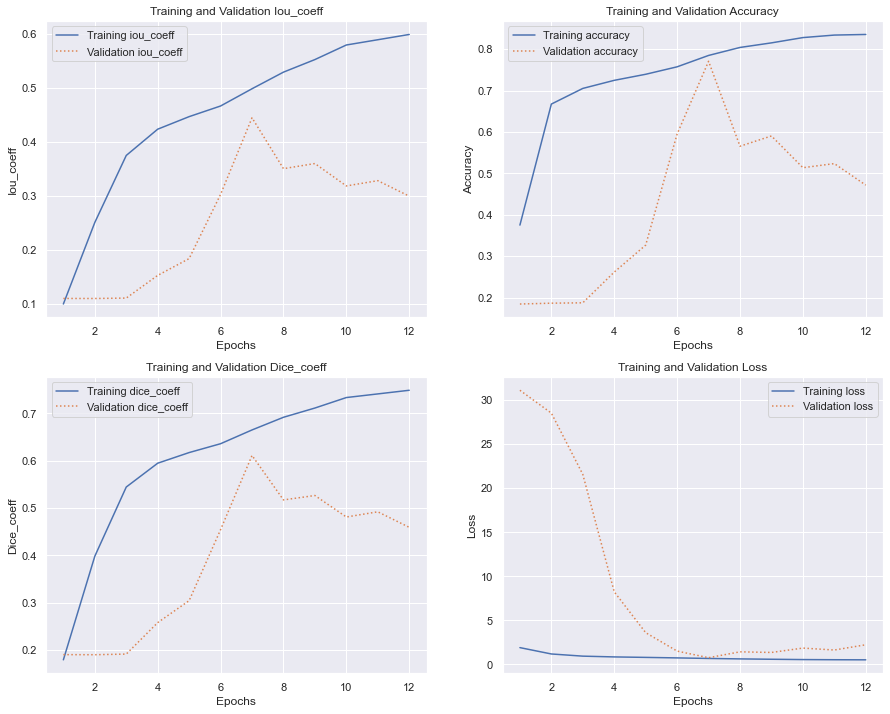

In [67]:
plot_hist(hist)

Le modèle overfit.  
Un autre backbone est testé à l'étape suivante.  

In [68]:
results = add_results(
    results, 
    model_name, 
    backbone, 
    loss_res(loss), 
    nb_epochs_train, 
    sample_size, 
    batch_size, 
    augmentation, 
    iou_score, 
    fit_time,
    fit_time_per_epochs)

save_model(model, test_number)

#### Test avec autre backbone

In [129]:
# test configuration

test_number = '2'

model_name = 'Unet'
backbone = 'resnet50'

loss= 'categorical_crossentropy'
augmentation = 'no'

sample_size = 200
batch_size = 16
epochs = 20

In [130]:
# stop when no iou improve
es = EarlyStopping(
    monitor='val_iou_coeff', 
    patience=5, 
    mode = 'max',
    restore_best_weights=True
)

# define and compile model
model = sm.Unet(backbone, input_shape=input_shape, classes=classes, activation='softmax', encoder_weights='imagenet')
model.compile(optimizer='adam', loss=loss, metrics=metrics)

# data generator
train_gen = DataGenerator(train_images_list, train_mask_list, batch_size, input_dims, backbone, augment=False)
val_gen = DataGenerator(val_images_list, val_mask_list, 1, input_dims, backbone)

# fit model
start_time = time.time()
hist = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=[es])
fit_time = time.time() - start_time

# best results
iou_score = round(es.best * 100, 2)
nb_epochs_train = epochs_train(es.stopped_epoch, epochs)
fit_time = round(fit_time)
fit_time_per_epochs = round(fit_time / nb_epochs_train)
print(f'\n iou_score : {iou_score}')


Epoch 1/20
13/13 [==============================] - 22s 1s/step - loss: 1.5832 - accuracy: 0.4462 - iou_coeff: 0.1697 - dice_coeff: 0.2851 - val_loss: 99.7104 - val_accuracy: 0.0776 - val_iou_coeff: 0.0414 - val_dice_coeff: 0.0777
Epoch 2/20
13/13 [==============================] - 16s 1s/step - loss: 0.8907 - accuracy: 0.7840 - iou_coeff: 0.3632 - dice_coeff: 0.5312 - val_loss: 43.9436 - val_accuracy: 0.1310 - val_iou_coeff: 0.0724 - val_dice_coeff: 0.1316
Epoch 3/20
13/13 [==============================] - 16s 1s/step - loss: 0.6353 - accuracy: 0.8322 - iou_coeff: 0.5059 - dice_coeff: 0.6713 - val_loss: 15.5138 - val_accuracy: 0.1610 - val_iou_coeff: 0.0942 - val_dice_coeff: 0.1650
Epoch 4/20
13/13 [==============================] - 16s 1s/step - loss: 0.5189 - accuracy: 0.8577 - iou_coeff: 0.5894 - dice_coeff: 0.7415 - val_loss: 13.1235 - val_accuracy: 0.1200 - val_iou_coeff: 0.0669 - val_dice_coeff: 0.1219
Epoch 5/20
13/13 [==============================] - 16s 1s/step - loss: 0.45

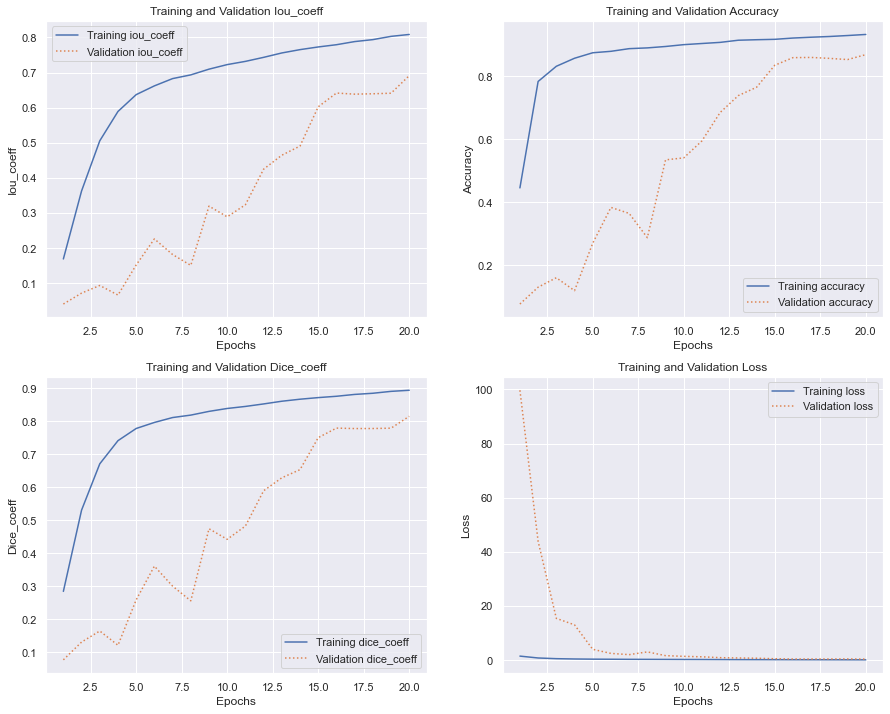

In [131]:
plot_hist(hist)

Les résultats sont meilleurs et il n'y a pas d'overfitting.

In [134]:
results = add_results(
    results, 
    model_name, 
    backbone, 
    loss_res(loss), 
    nb_epochs_train, 
    sample_size, 
    batch_size, 
    augmentation, 
    iou_score, 
    fit_time,
    fit_time_per_epochs)

save_model(model, test_number)

#### Autre architecture

In [91]:
# test configuration

test_number = '3'

model_name = 'Linknet'
backbone = 'resnet50'

loss= 'categorical_crossentropy'
augmentation = 'no'

sample_size = 200
batch_size = 16
epochs = 20

In [92]:
# stop when no iou improve
es = EarlyStopping(
    monitor='val_iou_coeff', 
    patience=5, 
    mode = 'max',
    restore_best_weights=True
)


# define and compile model
model = sm.Linknet(backbone, input_shape=input_shape, classes=classes, activation='softmax', encoder_weights='imagenet')
model.compile(optimizer='adam', loss=loss, metrics=metrics)

# data generator
train_gen = DataGenerator(train_images_list, train_mask_list, batch_size, input_dims, backbone, augment=False)
val_gen = DataGenerator(val_images_list, val_mask_list, 1, input_dims, backbone)

# fit model
start_time = time.time()
hist = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=[es])
fit_time = time.time() - start_time

# best results
iou_score = round(es.best * 100, 2)
nb_epochs_train = epochs_train(es.stopped_epoch, epochs)
fit_time = round(fit_time)
fit_time_per_epochs = round(fit_time / nb_epochs_train)
print(f'\n iou_score : {iou_score}')


Epoch 1/20
13/13 [==============================] - 22s 1s/step - loss: 1.5217 - accuracy: 0.5136 - iou_coeff: 0.1637 - dice_coeff: 0.2765 - val_loss: 7314.1733 - val_accuracy: 0.0753 - val_iou_coeff: 0.0401 - val_dice_coeff: 0.0753
Epoch 2/20
13/13 [==============================] - 16s 1s/step - loss: 0.9357 - accuracy: 0.7454 - iou_coeff: 0.3514 - dice_coeff: 0.5185 - val_loss: 1514.2450 - val_accuracy: 0.0754 - val_iou_coeff: 0.0402 - val_dice_coeff: 0.0754
Epoch 3/20
13/13 [==============================] - 16s 1s/step - loss: 0.7494 - accuracy: 0.7795 - iou_coeff: 0.4578 - dice_coeff: 0.6275 - val_loss: 546.1484 - val_accuracy: 0.0754 - val_iou_coeff: 0.0402 - val_dice_coeff: 0.0754
Epoch 4/20
13/13 [==============================] - 16s 1s/step - loss: 0.6097 - accuracy: 0.8071 - iou_coeff: 0.5330 - dice_coeff: 0.6951 - val_loss: 132.9549 - val_accuracy: 0.0805 - val_iou_coeff: 0.0429 - val_dice_coeff: 0.0803
Epoch 5/20
13/13 [==============================] - 16s 1s/step - loss

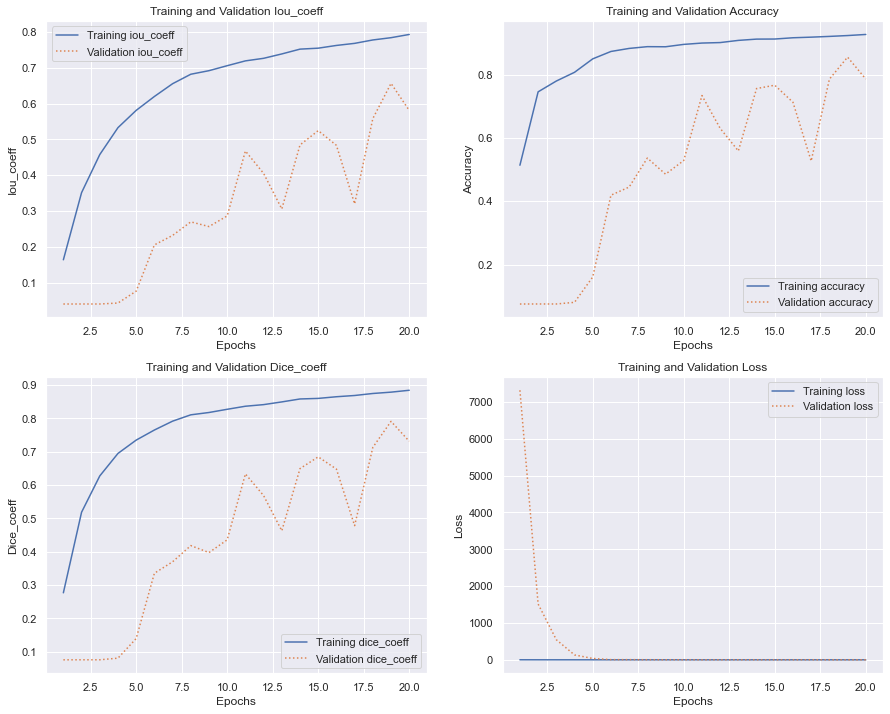

In [93]:
plot_hist(hist)

Le score est un peu moins bon qu'avec Unet.  
Unet, étant un standard, est conservé.

In [94]:
results = add_results(
    results, 
    model_name, 
    backbone, 
    loss_res(loss), 
    nb_epochs_train, 
    sample_size, 
    batch_size, 
    augmentation, 
    iou_score, 
    fit_time,
    fit_time_per_epochs)

save_model(model, test_number)


#### Fonction de perte

Test de Unet avec Dice Loss

In [123]:
# test configuration

test_number = '4'

model_name = 'Unet'
backbone = 'resnet50'

loss= dice_loss
augmentation = 'no'

sample_size = 200
batch_size = 16
epochs = 20

In [124]:
# stop when no iou improve
es = EarlyStopping(
    monitor='val_iou_coeff', 
    patience=5, 
    mode = 'max',
    restore_best_weights=True
)

# define and compile model
model = sm.Unet(backbone, input_shape=input_shape, classes=classes, activation='softmax', encoder_weights='imagenet')
model.compile(optimizer='adam', loss=loss, metrics=metrics)

# data generator
train_gen = DataGenerator(train_images_list, train_mask_list, batch_size, input_dims, backbone, augment=False)
val_gen = DataGenerator(val_images_list, val_mask_list, 1, input_dims, backbone)

# fit model
start_time = time.time()
hist = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=[es])
fit_time = time.time() - start_time

# best results
iou_score = round(es.best * 100, 2)
nb_epochs_train = epochs_train(es.stopped_epoch, epochs)
fit_time = round(fit_time)
fit_time_per_epochs = round(fit_time / nb_epochs_train)
print(f'\n iou_score : {iou_score}')


Epoch 1/20
13/13 [==============================] - 22s 1s/step - loss: 0.5964 - accuracy: 0.6039 - iou_coeff: 0.2664 - dice_coeff: 0.4100 - val_loss: 0.5884 - val_accuracy: 0.4109 - val_iou_coeff: 0.2601 - val_dice_coeff: 0.4116
Epoch 2/20
13/13 [==============================] - 16s 1s/step - loss: 0.3415 - accuracy: 0.7648 - iou_coeff: 0.4899 - dice_coeff: 0.6565 - val_loss: 0.5858 - val_accuracy: 0.4136 - val_iou_coeff: 0.2622 - val_dice_coeff: 0.4142
Epoch 3/20
13/13 [==============================] - 17s 1s/step - loss: 0.2595 - accuracy: 0.7864 - iou_coeff: 0.5888 - dice_coeff: 0.7408 - val_loss: 0.5649 - val_accuracy: 0.4428 - val_iou_coeff: 0.2802 - val_dice_coeff: 0.4351
Epoch 4/20
13/13 [==============================] - 17s 1s/step - loss: 0.2275 - accuracy: 0.7905 - iou_coeff: 0.6298 - dice_coeff: 0.7726 - val_loss: 0.6920 - val_accuracy: 0.4284 - val_iou_coeff: 0.1865 - val_dice_coeff: 0.3080
Epoch 5/20
13/13 [==============================] - 17s 1s/step - loss: 0.2049 -

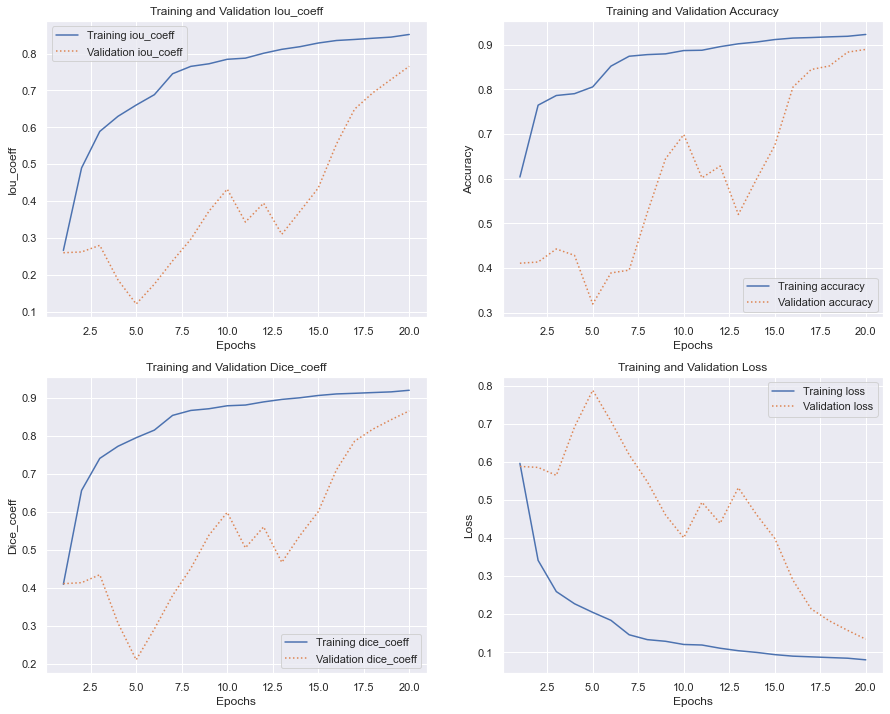

In [125]:
plot_hist(hist)

Le score est meilleur.  
Ce paramétrage est conservé.  
Test de l'entrainement du modèle sur plus d'images à l'étape suivante.

In [127]:
results = add_results(
    results, 
    model_name, 
    backbone, 
    loss_res(loss), 
    nb_epochs_train, 
    sample_size, 
    batch_size, 
    augmentation, 
    iou_score, 
    fit_time,
    fit_time_per_epochs)

save_model(model, test_number)


#### Entrainement avec plus d'images 

In [225]:
# test configuration

test_number = 5

model_name = 'Unet'
backbone = 'resnet50'

loss= dice_loss
augmentation = 'no'

sample_size = 500
batch_size = 16
epochs = 20

In [226]:
# stop when no iou improve
es = EarlyStopping(
    monitor='val_iou_coeff', 
    patience=5, 
    mode = 'max',
    restore_best_weights=True
)

# define and compile model
model = sm.Unet(backbone, input_shape=input_shape, classes=classes, activation='softmax', encoder_weights='imagenet')
model.compile(optimizer='adam', loss=loss, metrics=metrics)

# data generator
train_gen = DataGenerator(train_images_list, train_mask_list, batch_size, input_dims, backbone, augment=False)
val_gen = DataGenerator(val_images_list, val_mask_list, 1, input_dims, backbone)

# fit model
start_time = time.time()
hist = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=[es])
fit_time = time.time() - start_time

# best results
iou_score = round(es.best * 100, 2)
nb_epochs_train = epochs_train(es.stopped_epoch, epochs)
fit_time = round(fit_time)
fit_time_per_epochs = round(fit_time / nb_epochs_train)
print(f'\n iou_score : {iou_score}')


Epoch 1/20
32/32 [==============================] - 48s 1s/step - loss: 0.4939 - accuracy: 0.6516 - iou_coeff: 0.3580 - dice_coeff: 0.5093 - val_loss: 0.8435 - val_accuracy: 0.1565 - val_iou_coeff: 0.0881 - val_dice_coeff: 0.1565
Epoch 2/20
32/32 [==============================] - 41s 1s/step - loss: 0.2487 - accuracy: 0.7928 - iou_coeff: 0.6058 - dice_coeff: 0.7531 - val_loss: 0.8426 - val_accuracy: 0.1571 - val_iou_coeff: 0.0885 - val_dice_coeff: 0.1574
Epoch 3/20
32/32 [==============================] - 43s 1s/step - loss: 0.1861 - accuracy: 0.8382 - iou_coeff: 0.6897 - dice_coeff: 0.8152 - val_loss: 0.7227 - val_accuracy: 0.2828 - val_iou_coeff: 0.1643 - val_dice_coeff: 0.2773
Epoch 4/20
32/32 [==============================] - 43s 1s/step - loss: 0.1640 - accuracy: 0.8463 - iou_coeff: 0.7219 - dice_coeff: 0.8374 - val_loss: 0.7255 - val_accuracy: 0.2763 - val_iou_coeff: 0.1606 - val_dice_coeff: 0.2745
Epoch 5/20
32/32 [==============================] - 43s 1s/step - loss: 0.1506 -

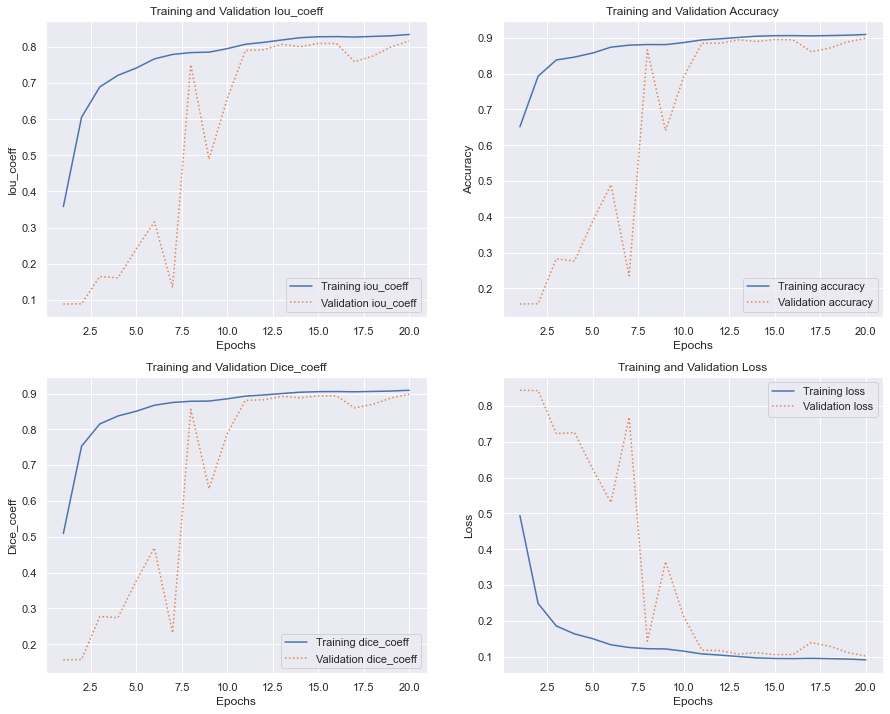

In [227]:
plot_hist(hist)

Le score est amélioré.  
La validation rejoint l'entrainement.  

In [228]:
results = add_results(
    results, 
    model_name, 
    backbone, 
    loss_res(loss), 
    nb_epochs_train, 
    sample_size, 
    batch_size, 
    augmentation, 
    iou_score, 
    fit_time,
    fit_time_per_epochs)

save_model(model, test_number)


#### Avec augmentation


In [541]:
# test configuration

test_number = 6

model_name = 'Unet'
backbone = 'resnet50'

loss= dice_loss
augmentation = 'yes'

sample_size = 500
batch_size = 16
epochs = 20


In [542]:
# get datas files lists
train_images_list, val_images_list, train_mask_list, val_mask_list = load_data(
    sample_size = sample_size, 
    val_split = 0.1, 
    data_type = 'train')

In [543]:
# stop when no iou improve
es = EarlyStopping(
    monitor='val_iou_coeff', 
    patience=5, 
    mode = 'max',
    restore_best_weights=True
)

# define and compile model
model = sm.Unet(backbone, input_shape=input_shape, classes=classes, activation='softmax', encoder_weights='imagenet')
model.compile(optimizer='adam', loss=loss, metrics=metrics)

# data generator
train_gen = DataGenerator(train_images_list, train_mask_list, batch_size, input_dims, backbone, augment=True)
val_gen = DataGenerator(val_images_list, val_mask_list, 1, input_dims, backbone)

# fit model
start_time = time.time()
hist = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=[es])
fit_time = time.time() - start_time

# best results
iou_score = round(es.best * 100, 2)
nb_epochs_train = epochs_train(es.stopped_epoch, epochs)
fit_time = round(fit_time)
fit_time_per_epochs = round(fit_time / nb_epochs_train)
print(f'\n iou_score : {iou_score}')

Epoch 1/20
32/32 [==============================] - 49s 1s/step - loss: 0.4967 - accuracy: 0.5990 - iou_coeff: 0.3508 - dice_coeff: 0.5046 - val_loss: 0.8431 - val_accuracy: 0.1569 - val_iou_coeff: 0.0883 - val_dice_coeff: 0.1569
Epoch 2/20
32/32 [==============================] - 39s 1s/step - loss: 0.3038 - accuracy: 0.7119 - iou_coeff: 0.5351 - dice_coeff: 0.6963 - val_loss: 0.7768 - val_accuracy: 0.2234 - val_iou_coeff: 0.1268 - val_dice_coeff: 0.2232
Epoch 3/20
32/32 [==============================] - 39s 1s/step - loss: 0.2742 - accuracy: 0.7429 - iou_coeff: 0.5737 - dice_coeff: 0.7273 - val_loss: 0.8228 - val_accuracy: 0.1760 - val_iou_coeff: 0.0996 - val_dice_coeff: 0.1772
Epoch 4/20
32/32 [==============================] - 40s 1s/step - loss: 0.2319 - accuracy: 0.7768 - iou_coeff: 0.6283 - dice_coeff: 0.7700 - val_loss: 0.7550 - val_accuracy: 0.2459 - val_iou_coeff: 0.1429 - val_dice_coeff: 0.2450
Epoch 5/20
32/32 [==============================] - 42s 1s/step - loss: 0.2133 -

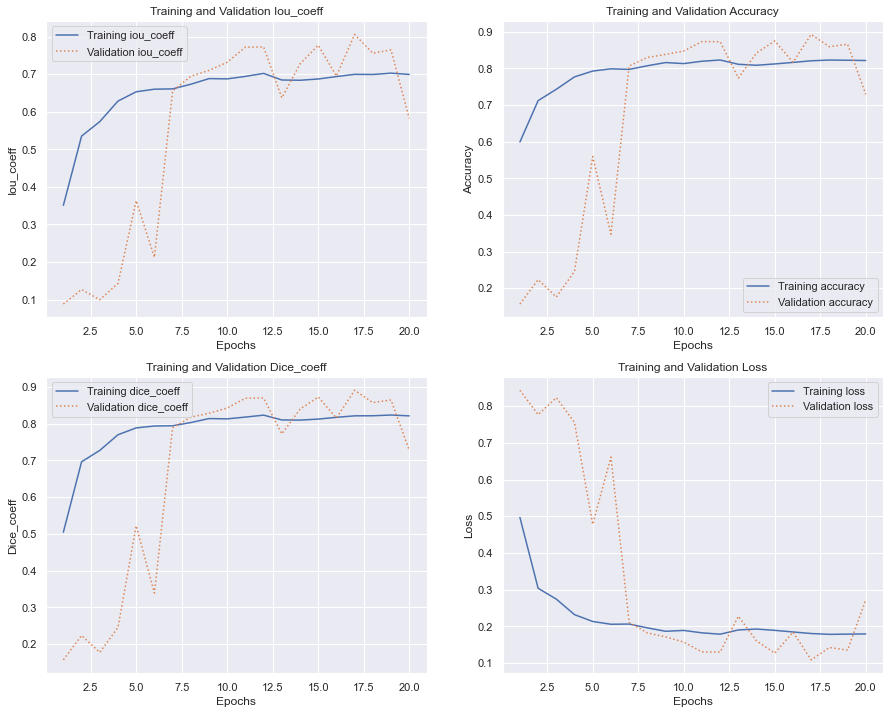

In [544]:
plot_hist(hist)

Le score est un peu moins bon qu'à l'étape précédente.  
Il serait intéressant de tester sur un plus grand nombre d'images avec plus de ressources de calcul.

In [545]:
results = add_results(
    results, 
    model_name, 
    backbone, 
    loss_res(loss), 
    nb_epochs_train, 
    sample_size, 
    batch_size, 
    augmentation, 
    iou_score, 
    fit_time,
    fit_time_per_epochs)

save_model(model, test_number)


### 4.4 - Résultats <a class="anchor" id="section_4_4"></a>

In [702]:
results

,model,backbone,loss,epochs,sample,batchsize,augmentation,iou_score,fit_time,time_per_epoch
0,Unet,vgg16,crossentropy,12,200,16,no,44.46,209,17
1,Unet,resnet50,crossentropy,20,200,16,no,69.13,344,17
2,Linknet,resnet50,crossentropy,20,200,16,no,65.66,332,17
3,Unet,resnet50,dice_loss,20,200,16,no,76.53,350,18
4,Unet,resnet50,dice_loss,20,500,16,no,81.72,857,43
5,Unet,resnet50,dice_loss,20,500,16,yes,80.57,962,48


1) La baseline Unet / VGG16 / crossentropy a obtenu un iou score de 44,46.
    Le nombre d’epochs s’est arrêté à 12 par un early-stopping.
    Le score sur les données de validation n’augmentait plus, contrairement aux données 
    d’entraînement. Nous sommes ici dans un cas d’overfitting.

2) Avec le backbone resnet50, le score est de 69,13, c’est celui-ci qui a été retenu.

3) Avec un réseau Linknet , le score est de 65,66, un peu inférieur au score précédent.

4) Unet/resnet50 a été conservé et entraîné avec une fonction de perte « dice loss ». 
    Le score a été clairement amélioré à 76,53. 

5) Il est intéressant d’essayer d’entraîner ce modèle avec plus d’images.
     Le score a été amélioré à 81,72.

6) Avec l’augmentation des données, le score est similaire, mais il est un peu inférieur à l’essai
    précédent. Pour que la data augmentation apporte un plus, il faudrait entraîner le modèle sur 
    beaucoup plus d’images afin qu’il y ait de nombreuses images augmentées.

Le modèle (5) Unet/resnet50 entraîne sur 500 images avec « dice loss » a été retenu, avec un Iou score de 81,72.


### 4.5 - Evaluation <a class="anchor" id="section_4_5"></a>

Le jeu de test téléchargé depuis cityscape contient des masques ne semblant pas utilsable.  
Pour évaluer le modèle final sur des images inconnues du modèle:  
Création d'une fonction permettant de charger de nouvelles images en connaissant la liste des images déjà utilisées. 

In [525]:
def load_tests_lists(images_dir, masks_dir, used_images_list, used_masks_list, nb_files, mask_type):
    test_images_list = tests_list(images_dir, used_images_list, nb_files, mask_type)
    test_masks_list = tests_list(masks_dir, used_masks_list, nb_files, mask_type, True)
    return test_images_list, test_masks_list

def tests_list(files_dir, used_files_list, nb_files, mask_type, label_files = False):

    files_list=[]
    nb_reste = nb_files
    i=0

    for idx,town_dir in enumerate(os.listdir(files_dir)):
        current_town_list = os.listdir(files_dir + town_dir)
        current_town_list = [files_dir + town_dir + '/' + filename for filename in current_town_list]
        
        if label_files:
            current_town_list = [x for x in current_town_list if mask_type in x ]

        current_town_used_list = [x for x in used_files_list if town_dir in x ]
        
        start = len(current_town_used_list)

        if len(current_town_list) - len(current_town_used_list) >= nb_reste:
            nb_curr = nb_reste
        else:
            nb_curr = len(current_town_list) - len(current_town_used_list)

        new_list = current_town_list[start:start + nb_curr]
        files_list.extend(new_list)

        nb_reste = nb_reste - nb_curr
        if nb_reste == 0:
            break
            
    return files_list

In [868]:
model = tf.keras.models.load_model('./models/model_5.h5', compile=False)

In [869]:
test_images_list, test_masks_list = load_tests_lists(val_images_dir, val_masks_dir, val_images_list, val_mask_list, 100, 'labelIds')


In [870]:
test_gen = DataGenerator(test_images_list, test_masks_list, 1, input_dims, backbone)

model.compile(optimizer='adam', loss=loss, metrics=metrics)

score_test = model.evaluate(test_gen)


100/100 [==============================] - 9s 75ms/step - loss: 0.1533 - accuracy: 0.8475 - iou_coeff: 0.7379 - dice_coeff: 0.8467


In [875]:
print(f'Iou test score : {np.round(score_test[2]*100,2)}%')

Iou test score : 73.79%


## 5 - Prédictions <a class="anchor" id="chapter5"></a>

In [500]:

from PIL import Image

def predict(image):
    

    dims = image.shape
    image_source = Image.fromarray(image)
    image_source_rsz = image_source.resize((224, 224))
    image_rsz = np.array(image_source_rsz)
    
    x = np.expand_dims(image_rsz, axis=0)
    x = keras_preprocess_input_resnet(x)

    z = model.predict(x)
    
    z = np.squeeze(z)
    z = z.reshape(224, 224, 8)
    y = np.argmax(z, axis=2)
    
    color_map = {
        '0': [0, 0, 0],
        '1': [153, 153, 0],
        '2': [255, 204, 204],
        '3': [255, 0, 127],
        '4': [0, 255, 0],
        '5': [0, 204, 204],
        '6': [255, 0, 0],
        '7': [0, 0, 255]
    }

    img_color = image_rsz.copy()   
    for i in range(224):
        for j in range(224):
            img_color[i, j] = color_map[str(y[i, j])]
            
    img_color_pred = Image.fromarray(img_color)
    img_color_rsz = img_color_pred.resize((dims[1], dims[0]))
    
    return img_color_rsz


In [502]:

def test_predict(image_file, color_file):
    image_source = load_image(image_file)
    image_mask = load_image(color_file)
    image_mask_pred = predict(np.array(image_source))
    plot_prediction(image_source, image_mask, image_mask_pred)
    
def load_image(img_path):
    img_source = Image.open(img_path).convert("RGB")
    return img_source
    
def plot_prediction(image_source, image_mask, image_mask_pred):
    plt.figure(figsize=(15,8))
    plt.subplot(1,3,1)
    affiche_image(image_source)
    plt.subplot(1,3,2)
    affiche_image(image_mask)
    plt.subplot(1,3,3)
    affiche_image(image_mask_pred)


In [503]:
image_file_t1, color_file_t1, instance_file_t1, label_file_t1 = get_file('train',0,0)
image_file_v1, color_file_v1, instance_file_v1, label_file_v1 = get_file('val',2,20)


In [504]:
model = tf.keras.models.load_model('./models/model_5.h5', compile=False)

##### Prédiction sur une image déjà connue du modèle:

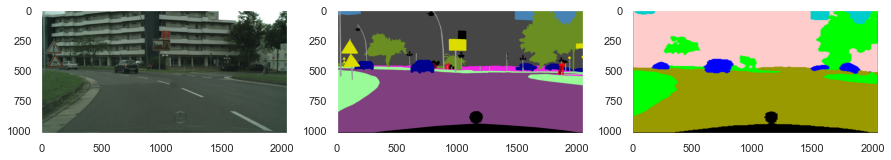

In [505]:
test_predict(image_file_t1, color_file_t1)

##### Prédiction sur une image inconnue du modèle:

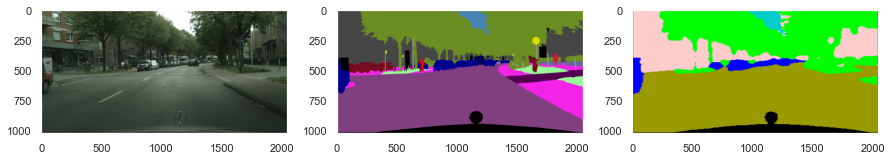

In [506]:
test_predict(image_file_v1, color_file_v1)

#### test avec serialisation des donnees:

In [ ]:
import json, pickle

def test_predict_on_deployed_mock(image_file, color_file):
    image_source = load_image(image_file)
    image_mask = load_image(color_file)
    datas_to_send = json.dumps(pickle.dumps(np.array(image_source)).decode('latin-1'))
    resp = model_deployed_run_mock(datas_to_send)
    image_mask_pred = pickle.loads(json.loads(resp).encode('latin-1'))
    plot_prediction(image_source, image_mask, image_mask_pred)

def model_deployed_run_mock(raw_data):
    deserialized_from_json = pickle.loads(json.loads(raw_data).encode('latin-1'))
    img_color = predict(deserialized_from_json)
    serialized_as_json = json.dumps(pickle.dumps(img_color).decode('latin-1'))
    return serialized_as_json

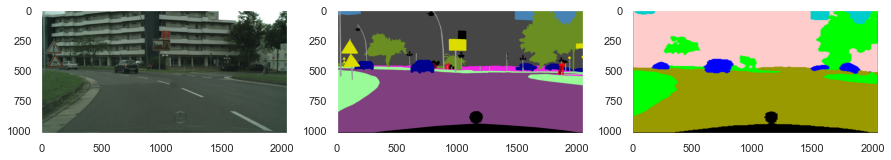

In [507]:
test_predict_on_deployed_mock(image_file_t1, color_file_t1)

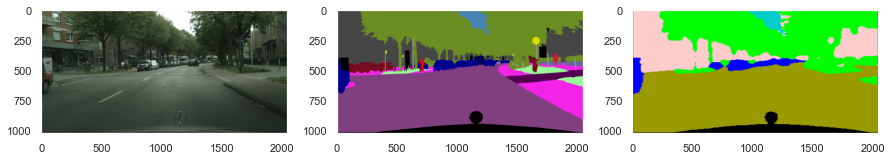

In [508]:
test_predict_on_deployed_mock(image_file_v1, color_file_v1)

## 6 - Création d'un jeu de tests <a class="anchor" id="chapter6"></a>

Génération d'un jeu d'images contenant :  
- des images et leurs masques utilisés pour l'entrainement  
- des images et leurs masques utilisés pour la validation  
- des images et leurs masques inconnus du modèle

Sauvegarde des fichiers dans des répertoires image et mask

In [526]:
test_images_list_demo, test_mask_list_demo = load_tests_lists(val_images_dir, val_masks_dir, val_images_list, val_mask_list, 5, 'color')

train_images_list_demo = train_images_list[:5]

train_mask_list_demo = train_mask_list[:5]
train_mask_list_demo = [x.replace('labelIds','color') for x in train_mask_list_demo]

val_images_list_demo = val_images_list[:5]

val_mask_list_demo = val_mask_list[:5]
val_mask_list_demo = [x.replace('labelIds','color') for x in val_mask_list_demo]


In [527]:
import shutil

api_dir = './datas/test_dest/'

for file in test_images_list_demo:
    shutil.copy(file, api_dir + 'image')
    
for file in test_mask_list_demo:
    shutil.copy(file, api_dir + 'mask')
    
for file in train_images_list_demo:
    shutil.copy(file, api_dir + 'image')
    
for file in train_mask_list_demo:
    shutil.copy(file, api_dir + 'mask')

for file in val_images_list_demo:
    shutil.copy(file, api_dir + 'image')
    
for file in val_mask_list_demo:
    shutil.copy(file, api_dir + 'mask')
    
    

## 7 - Conclusion <a class="anchor" id="chapter7"></a>

La modélisation a permis d’obtenir un iou score de plus de 80 %.  
Ce résultat a été obtenu après avoir comparé plusieurs architectures de réseaux de neurones avec différents backbones. 

Pour améliorer les performances, différentes pistes peuvent être étudiées :

- L’entraînement du modèle sur beaucoup plus d’images et plus d’epochs
  Pour cela, il faut avoir des ressources de calcul conséquentes. 
- La génération de nouvelles données à partir du jeu d’entraînement suffisamment important.
- Tester d’autres techniques d’augmentation de données
- Optimisation du batch size à la génération de données
- Tester d’autres architectures et backbones
